In [8]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk upward until we find the project root."""
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "ml_engine").exists():
            return path
    raise RuntimeError("Could not find project root from current working directory")


repo_root = _find_repo_root(Path.cwd().resolve())
sam_pkg_root = repo_root / "deps" / "segment_anything"

# Ensure local source packages win over site-packages / namespace collisions.
for p in [sam_pkg_root, repo_root]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

# Clear possibly broken namespace import (e.g. empty repo_root/segment_anything).
sys.modules.pop("segment_anything", None)

print("repo_root:", repo_root)
print("segment_anything source:", sam_pkg_root)

repo_root: /home/shen_h/platform/Grounded-Segment-Anything
segment_anything source: /home/shen_h/platform/Grounded-Segment-Anything/deps/segment_anything


In [9]:
from ml_engine.models.teacher.sam_lora import load_sam_hq_with_lora
from segment_anything.utils.transforms import ResizeLongestSide
import torch

In [135]:
SAM_PIXEL_MEAN = torch.tensor([123.675, 116.28, 103.53]).view(3, 1, 1)
SAM_PIXEL_STD = torch.tensor([58.395, 57.12, 57.375]).view(3, 1, 1)

In [122]:
base_check_path = "/home/shen_h/platform/Grounded-Segment-Anything/data/models/pretrained/sam_hq_vit_b.pth"
lora_path = "/home/shen_h/platform/Grounded-Segment-Anything/experiments/teacher_training_8192b41f/sam/lora_adapters"

In [123]:
model = load_sam_hq_with_lora(base_check_path, lora_path, model_type="vit_b", merge=True)
model

<All keys matched successfully>


SAMHQLoRA(
  (model): Sam(
    (image_encoder): ImageEncoderViT(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (blocks): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (lin1): Linear(in_features=768, out_features=3072, bias=True)
            (lin2): Linear(in_features=3072, out_features=768, bias=True)
            (act): GELU(approximate='none')
          )
        )
      )
      (neck): Sequential(
        (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): LayerNorm2d()
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride

In [124]:
model.eval();

In [126]:
transform = ResizeLongestSide(1024)
transform

In [127]:
import cv2

image_path = "/srv/shared/images/upload/2025/12/17/boxes/rgb_image_20251229_141856_146.png"
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print("shape:", image_bgr.shape)

shape: (1200, 1920, 3)


In [149]:
resized = transform.apply_image(image_rgb)
resized.shape

(640, 1024, 3)

In [150]:
img_tensor = torch.from_numpy(resized).permute(2, 0, 1).float()
img_tensor.shape
img_tensor

tensor([[[ 33.,  34.,  35.,  ...,  44.,  44.,  23.],
         [ 62.,  65.,  69.,  ...,  83.,  82.,  43.],
         [ 65.,  67.,  72.,  ...,  84.,  82.,  43.],
         ...,
         [ 96.,  92.,  90.,  ..., 244., 247., 252.],
         [ 99.,  96.,  96.,  ..., 245., 247., 253.],
         [102., 101., 101.,  ..., 244., 245., 251.]],

        [[ 31.,  33.,  35.,  ...,  46.,  45.,  24.],
         [ 60.,  63.,  66.,  ...,  86.,  85.,  45.],
         [ 62.,  66.,  70.,  ...,  87.,  86.,  45.],
         ...,
         [ 82.,  79.,  76.,  ..., 228., 233., 240.],
         [ 83.,  81.,  80.,  ..., 235., 240., 246.],
         [ 83.,  82.,  81.,  ..., 232., 235., 243.]],

        [[ 34.,  36.,  37.,  ...,  53.,  52.,  28.],
         [ 65.,  68.,  71.,  ..., 100.,  99.,  52.],
         [ 67.,  72.,  76.,  ..., 100.,  99.,  53.],
         ...,
         [ 72.,  70.,  66.,  ..., 236., 239., 243.],
         [ 69.,  68.,  66.,  ..., 244., 247., 252.],
         [ 65.,  65.,  64.,  ..., 241., 244., 249.]]]

In [151]:
img_tensor = (img_tensor - SAM_PIXEL_MEAN) / (SAM_PIXEL_STD + 1e-8)
img_tensor.max()

tensor(2.6400)

In [ ]:
_, H, W = img_tensor.shape
padded = torch.zeros(3, 1024, 1024)
padded[:, :H, :W] = img_tensor
padded




tensor([[[-1.5528, -1.5357, -1.5185,  ..., -1.3644, -1.3644, -1.7240],
         [-1.0562, -1.0048, -0.9363,  ..., -0.6965, -0.7137, -1.3815],
         [-1.0048, -0.9705, -0.8849,  ..., -0.6794, -0.7137, -1.3815],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[-1.4930, -1.4580, -1.4230,  ..., -1.2304, -1.2479, -1.6155],
         [-0.9853, -0.9328, -0.8803,  ..., -0.5301, -0.5476, -1.2479],
         [-0.9503, -0.8803, -0.8102,  ..., -0.5126, -0.5301, -1.2479],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[-1.2119, -1.1770, -1.1596,  ..., -0.8807, -0.8981, -1.3164],
         [-0.6715, -0.6193, -0.5670,  ..., -0

: 

In [16]:
import os
os.chdir(repo_root)

from ml_engine.inference.detectors.grounding_dino import GroundingDINODetector
from PIL import Image
import numpy as np

In [17]:
dino_detector = GroundingDINODetector(
    config_path=str(repo_root / "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"),
    checkpoint_path=str(repo_root / "data/models/pretrained/groundingdino_swint_ogc.pth"),
)

In [18]:
import cv2

image_path = "/srv/shared/images/upload/2025/12/17/boxes/rgb_image_20251229_141856_146.png"
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print("shape:", image_bgr.shape)

shape: (1200, 1920, 3)


In [19]:
dino_detector.detect(image_bgr, ["box"])

use local bert model path: data/models/pretrained/bert-base-uncased


DetectionResult(boxes_xyxy=array([[1.82710281e+02, 5.56128540e+02, 6.45967224e+02, 9.90201904e+02],
       [6.21015320e+02, 5.51895813e+02, 1.01623517e+03, 8.67529480e+02],
       [1.27288391e+02, 2.70234863e+02, 5.48007324e+02, 6.44870789e+02],
       [9.47905884e+02, 3.88839722e-01, 1.61177551e+03, 4.17492432e+02],
       [3.96808411e+02, 4.27154541e-01, 8.52903015e+02, 5.66505249e+02],
       [7.94140259e+02, 1.80973022e+02, 1.40785803e+03, 7.68249207e+02]],
      dtype=float32), confidences=array([0.71781707, 0.7073517 , 0.6981108 , 0.651277  , 0.6303871 ,
       0.56633335], dtype=float32), class_ids=array([0, 0, 0, 0, 0, 0]))

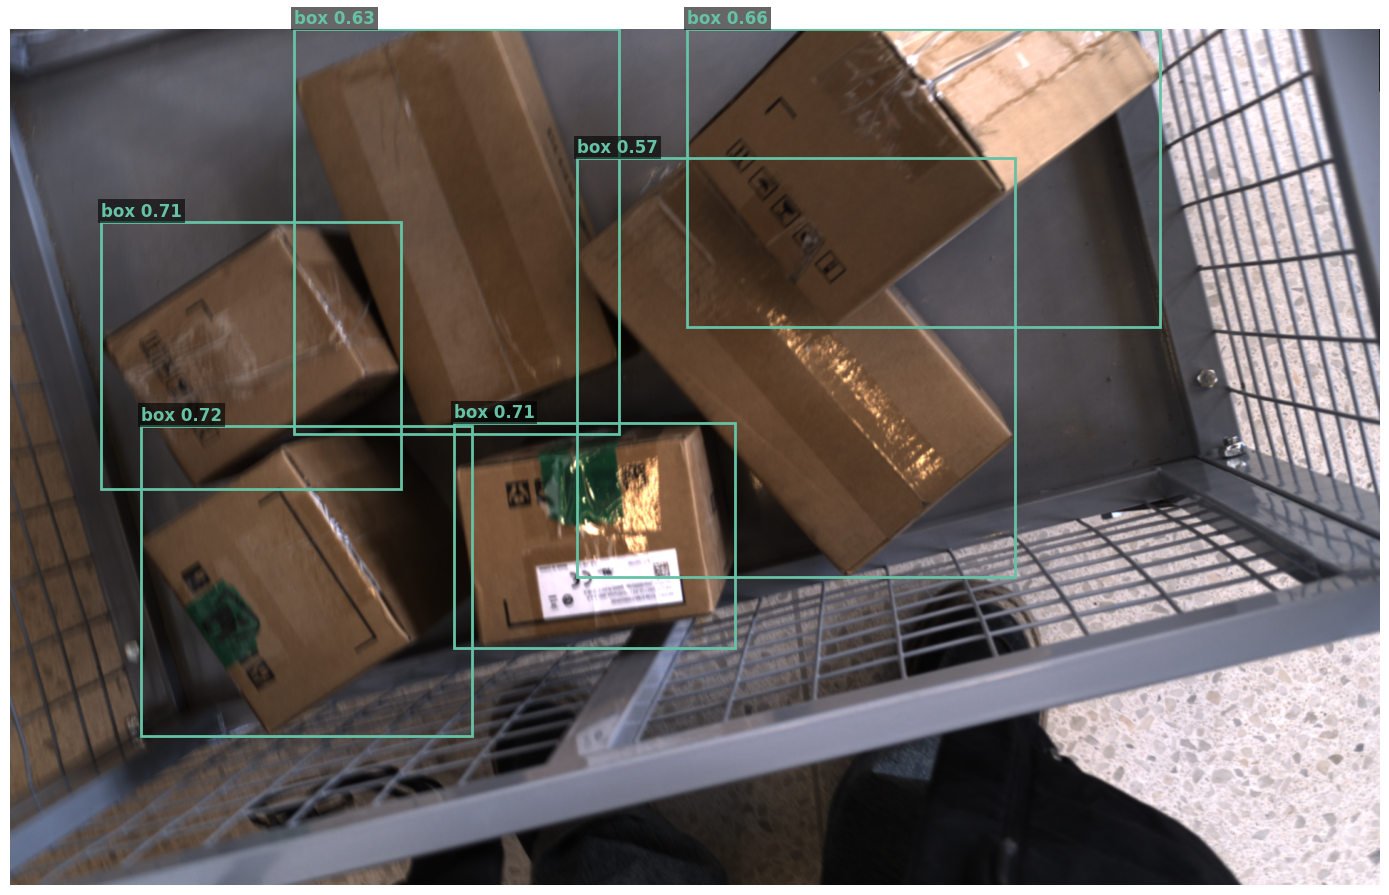

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result = dino_detector.detect(image_bgr, ["box", "pig"])

fig, ax = plt.subplots(1, figsize=(14, 10))
ax.imshow(image_rgb)

colors = plt.cm.Set2.colors
for i, (box, conf, cid) in enumerate(zip(result.boxes_xyxy, result.confidences, result.class_ids)):
    x1, y1, x2, y2 = box
    color = colors[cid % len(colors)]
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 8, f'box {conf:.2f}', color=color,
            fontsize=12, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none'))

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [21]:
from ml_engine.inference.segmenters.sam_hq import SAMHQSegmenter

sam_segmenter = SAMHQSegmenter(
    base_checkpoint=str(repo_root / "data/models/pretrained/sam_hq_vit_b.pth"),
    device="cuda",
)

result = dino_detector.detect(image_bgr, ["box"])
masks = sam_segmenter.segment(image_rgb, result.boxes_xyxy)
print(f"{len(masks)} masks, each shape: {masks[0].shape if masks else 'N/A'}")

(' Warning: Trainable ratio (%s%%) is high for LoRA! Expected < 5%%', 6.309042444447676)
 Non-LoRA trainable parameters found: ['base_model.model.mask_decoder.transformer.layers.0.self_attn.q_proj.weight', 'base_model.model.mask_decoder.transformer.layers.0.self_attn.q_proj.bias', 'base_model.model.mask_decoder.transformer.layers.0.self_attn.k_proj.weight', 'base_model.model.mask_decoder.transformer.layers.0.self_attn.k_proj.bias', 'base_model.model.mask_decoder.transformer.layers.0.self_attn.v_proj.weight']...


<All keys matched successfully>
6 masks, each shape: (1200, 1920)


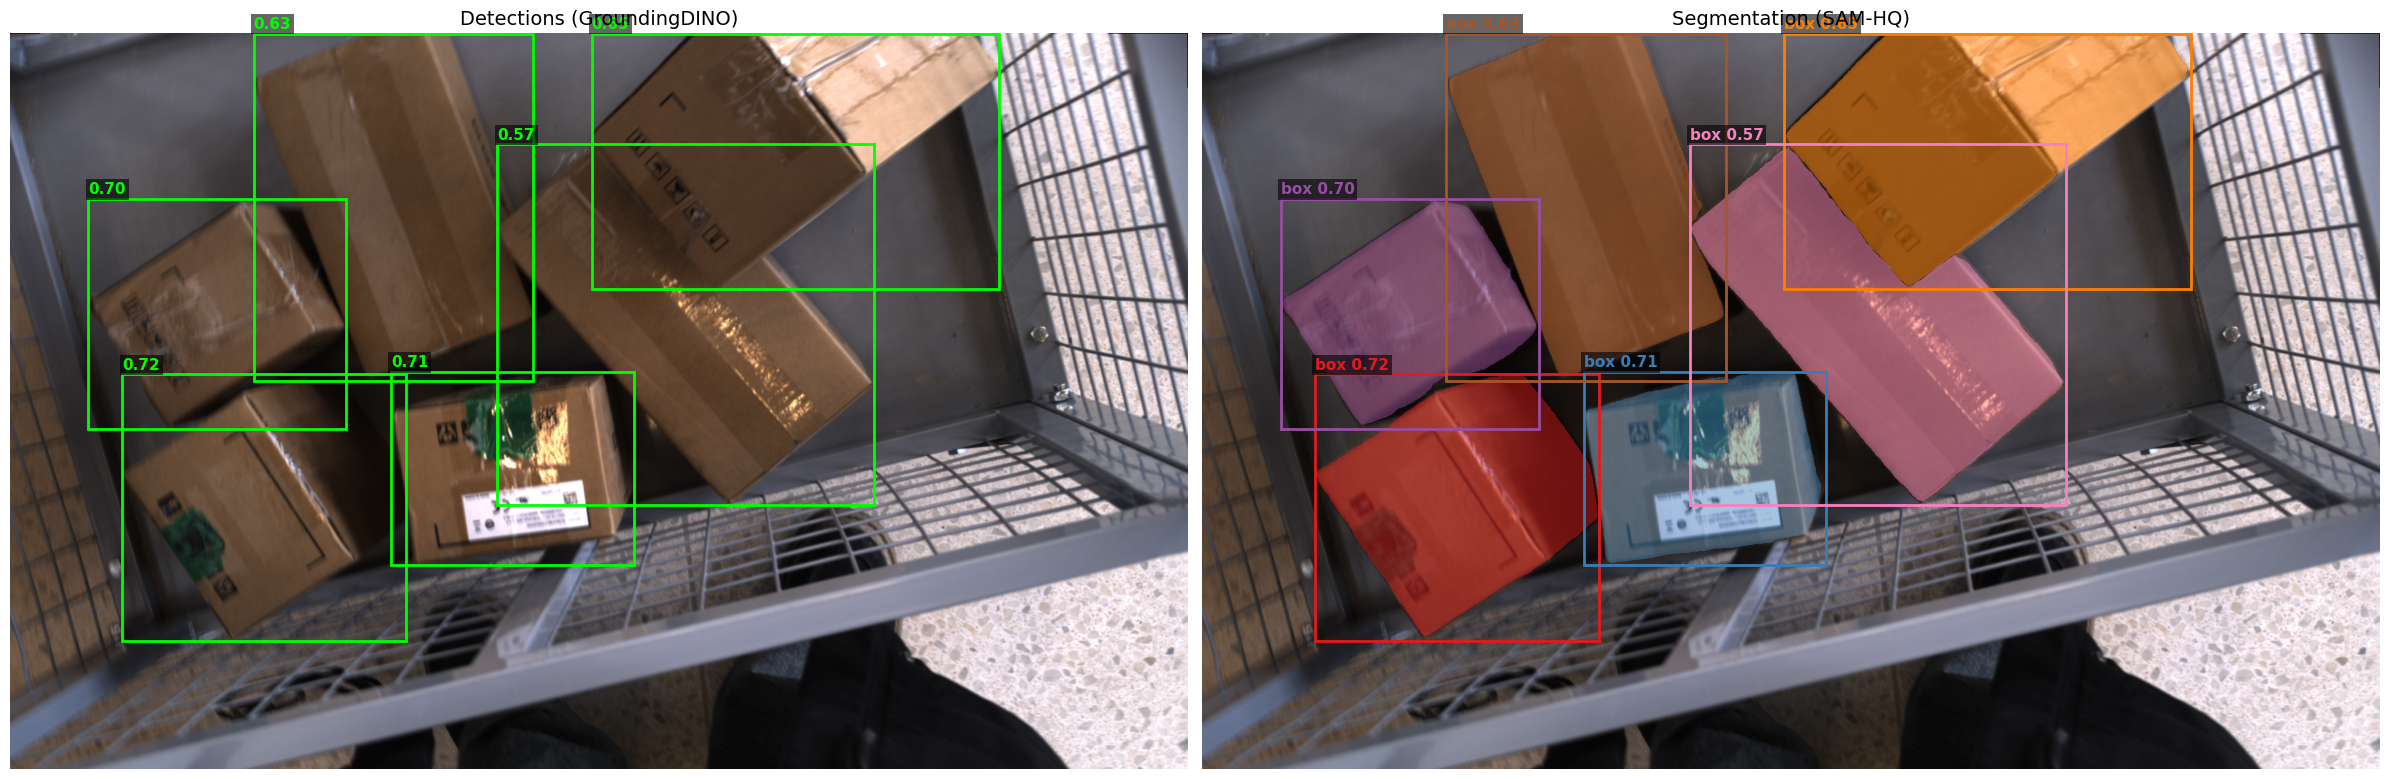

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left: boxes only
axes[0].imshow(image_rgb)
axes[0].set_title("Detections (GroundingDINO)", fontsize=14)
for box, conf in zip(result.boxes_xyxy, result.confidences):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x1, y1 - 8, f'{conf:.2f}', color='lime', fontsize=11,
                 fontweight='bold', bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none'))

# Right: masks overlay
axes[1].imshow(image_rgb)
axes[1].set_title("Segmentation (SAM-HQ)", fontsize=14)
cmap = plt.cm.Set1
for i, (mask, box, conf) in enumerate(zip(masks, result.boxes_xyxy, result.confidences)):
    color = cmap(i / max(len(masks), 1))
    overlay = np.zeros((*mask.shape, 4))
    overlay[mask > 0] = (*color[:3], 0.45)
    axes[1].imshow(overlay)
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(x1, y1 - 8, f'box {conf:.2f}', color=color, fontsize=11,
                 fontweight='bold', bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none'))

for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [23]:
import logging
from typing import Dict, List

import cv2
import numpy as np
import torch
from PIL import Image
from torchvision.ops import box_convert, nms

import groundingdino.datasets.transforms as T
from groundingdino.util.inference import load_model, preprocess_caption

from ml_engine.inference.detectors.base import DetectionResult

logger = logging.getLogger(__name__)


def build_positive_map(
    tokenizer,
    caption: str,
    num_classes: int,
) -> Dict[int, List[int]]:
    """Map each class index to its token positions in the tokenized caption.

    The caption is formatted as ``"class0. class1. class2."`` with ``.``
    as the delimiter.  The BERT tokenizer produces special tokens
    ([CLS], [SEP]) and punctuation (``.``, ``?``) that act as boundaries.
    Tokens between consecutive boundaries belong to one class.

    Equivalent to MMDetection's ``create_positive_map_label_to_token``.

    Returns:
        ``{class_idx: [token_pos, ...], ...}``
    """
    special_ids = set(
        tokenizer.convert_tokens_to_ids(["[CLS]", "[SEP]", ".", "?"])
    )
    input_ids = tokenizer(caption, return_tensors="pt")["input_ids"][0].tolist()

    positive_map: Dict[int, List[int]] = {}
    class_idx = 0
    prev = 0

    for pos, tid in enumerate(input_ids):
        if tid not in special_ids:
            continue
        span = list(range(prev + 1, pos))
        if span and class_idx < num_classes:
            positive_map[class_idx] = span
            class_idx += 1
        prev = pos

    return positive_map


def logits_to_class_scores(
    logits: torch.Tensor,
    positive_map: Dict[int, List[int]],
    num_classes: int,
) -> torch.Tensor:
    """Convert per-token logits to per-class scores via mean aggregation.

    Equivalent to MMDetection's ``convert_grounding_to_cls_scores``.

    Args:
        logits: Sigmoided token-level logits, shape ``(nq, max_text_len)``.
        positive_map: ``{class_idx: [token_positions]}``.
        num_classes: Total number of classes.

    Returns:
        Per-class scores, shape ``(nq, num_classes)``.
    """
    scores = torch.zeros(logits.shape[0], num_classes, device=logits.device)
    for cls_idx, tok_indices in positive_map.items():
        scores[:, cls_idx] = logits[:, tok_indices].mean(dim=-1)
    return scores


_IMAGE_TRANSFORM = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def preprocess_image(image_bgr: np.ndarray) -> torch.Tensor:
    """BGR ndarray → normalised tensor ready for GroundingDINO."""
    pil = Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    tensor, _ = _IMAGE_TRANSFORM(pil, None)
    return tensor

In [24]:
tokenizer = dino_detector._model.tokenizer

In [25]:
prompts = ["box", "pig with dog", "cats in a room"]
'.'.join(prompts)
caption = preprocess_caption(".".join(prompts))
print("caption:", caption)
build_positive_map(tokenizer, caption, len(prompts))

caption: box.pig with dog.cats in a room.


{0: [1], 1: [3, 4, 5], 2: [7, 8, 9, 10]}

In [78]:
special_ids = tokenizer.convert_tokens_to_ids(["[CLS]", "[SEP]", ".", "?"])
special_ids

[101, 102, 1012, 1029]

In [ ]:
input_ids = tokenizer(caption)["input_ids"]
input_ids

[101, 3482, 1012, 10369, 2007, 3899, 1012, 8870, 1999, 1037, 2282, 1012, 102]

we need to pick out the index of the tokens between each pair of special tokens

In [80]:
positive_map = build_positive_map(tokenizer, caption, len(prompts))
positive_map

{0: [1], 1: [3, 4, 5], 2: [7, 8, 9, 10]}

In [81]:
img_tensor = preprocess_image(image_bgr).to(dino_detector.device)
img_tensor.shape

torch.Size([3, 800, 1280])

In [82]:
model = dino_detector._model
model.eval()
with torch.no_grad():
    a = model(img_tensor[None], captions=[caption])



In [83]:
pred_logits_raw = a["pred_logits"]
pred_logits_raw.shape

torch.Size([1, 900, 256])

In [93]:
pred_logits = pred_logits_raw.sigmoid()[0]
pred_logits

tensor([[0.0053, 0.5791, 0.0101,  ..., 0.0000, 0.0000, 0.0000],
        [0.0057, 0.5404, 0.0131,  ..., 0.0000, 0.0000, 0.0000],
        [0.0053, 0.5651, 0.0105,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0014, 0.0135, 0.0017,  ..., 0.0000, 0.0000, 0.0000],
        [0.0010, 0.0244, 0.0015,  ..., 0.0000, 0.0000, 0.0000],
        [0.0015, 0.0139, 0.0013,  ..., 0.0000, 0.0000, 0.0000]],
       device='cuda:0')

based on the `pred_logits` we can calculate the scores for each potential class

In [101]:
class_scores = logits_to_class_scores(pred_logits, positive_map, len(prompts))
class_scores.shape, class_scores

(torch.Size([900, 3]),
 tensor([[0.5791, 0.0277, 0.0199],
         [0.5404, 0.0237, 0.0207],
         [0.5651, 0.0220, 0.0181],
         ...,
         [0.0135, 0.0042, 0.0025],
         [0.0244, 0.0044, 0.0038],
         [0.0139, 0.0077, 0.0061]], device='cuda:0'))

In [ ]:
type(class_scores.max(dim=-1)) # return (values, indices)
type(class_scores.max()) # return value

torch.Tensor

In [112]:
max_scores, class_ids = class_scores.max(dim=-1)
max_scores[max_scores > 0.5]

tensor([0.5791, 0.5404, 0.5651, 0.5799, 0.5057], device='cuda:0')

In [90]:
pred_box_raw = a["pred_boxes"]
pred_box_raw.shape

torch.Size([1, 900, 4])

In [92]:
pred_box_raw[0][0]

tensor([0.2142, 0.6433, 0.2399, 0.3601], device='cuda:0')

## Fine-tuned GroundingDINO (LoRA) — d98da9b9

Load the LoRA fine-tuned model from `experiments/teacher_training_d98da9b9` and compare detection results against the base model above.

In [26]:
from ml_engine.models.teacher.grounding_dino_lora import GroundingDINOLoRA

finetuned_lora = GroundingDINOLoRA.from_lora_checkpoint(
    base_checkpoint=str(repo_root / "data/models/pretrained/groundingdino_swint_ogc.pth"),
    lora_adapter_path=str(repo_root / "experiments/teacher_training_d98da9b9/grounding_dino/lora_adapters"),
    merge=True,
    bert_model_path=str(repo_root / "data/models/pretrained/bert-base-uncased"),
)
finetuned_lora.eval()

# Wrap the merged model into a GroundingDINODetector so we can reuse .detect()
finetuned_detector = GroundingDINODetector.__new__(GroundingDINODetector)
finetuned_detector.device = torch.device("cuda")
finetuned_detector._model = finetuned_lora.model.to(finetuned_detector.device)
finetuned_detector._model.eval()
print("Fine-tuned GroundingDINO loaded and ready.")

use local bert model path: /home/shen_h/platform/Grounded-Segment-Anything/data/models/pretrained/bert-base-uncased


Unexpected keys (2): ['label_enc.weight', 'bert.embeddings.position_ids']...


Fine-tuned GroundingDINO loaded and ready.


In [27]:
result_finetuned = finetuned_detector.detect(image_bgr, ["box"])
print(f"Fine-tuned detections: {len(result_finetuned.boxes_xyxy)}")
print(f"Score range: [{result_finetuned.confidences.min():.4f}, {result_finetuned.confidences.max():.4f}]")

Fine-tuned detections: 6
Score range: [0.7552, 0.8072]


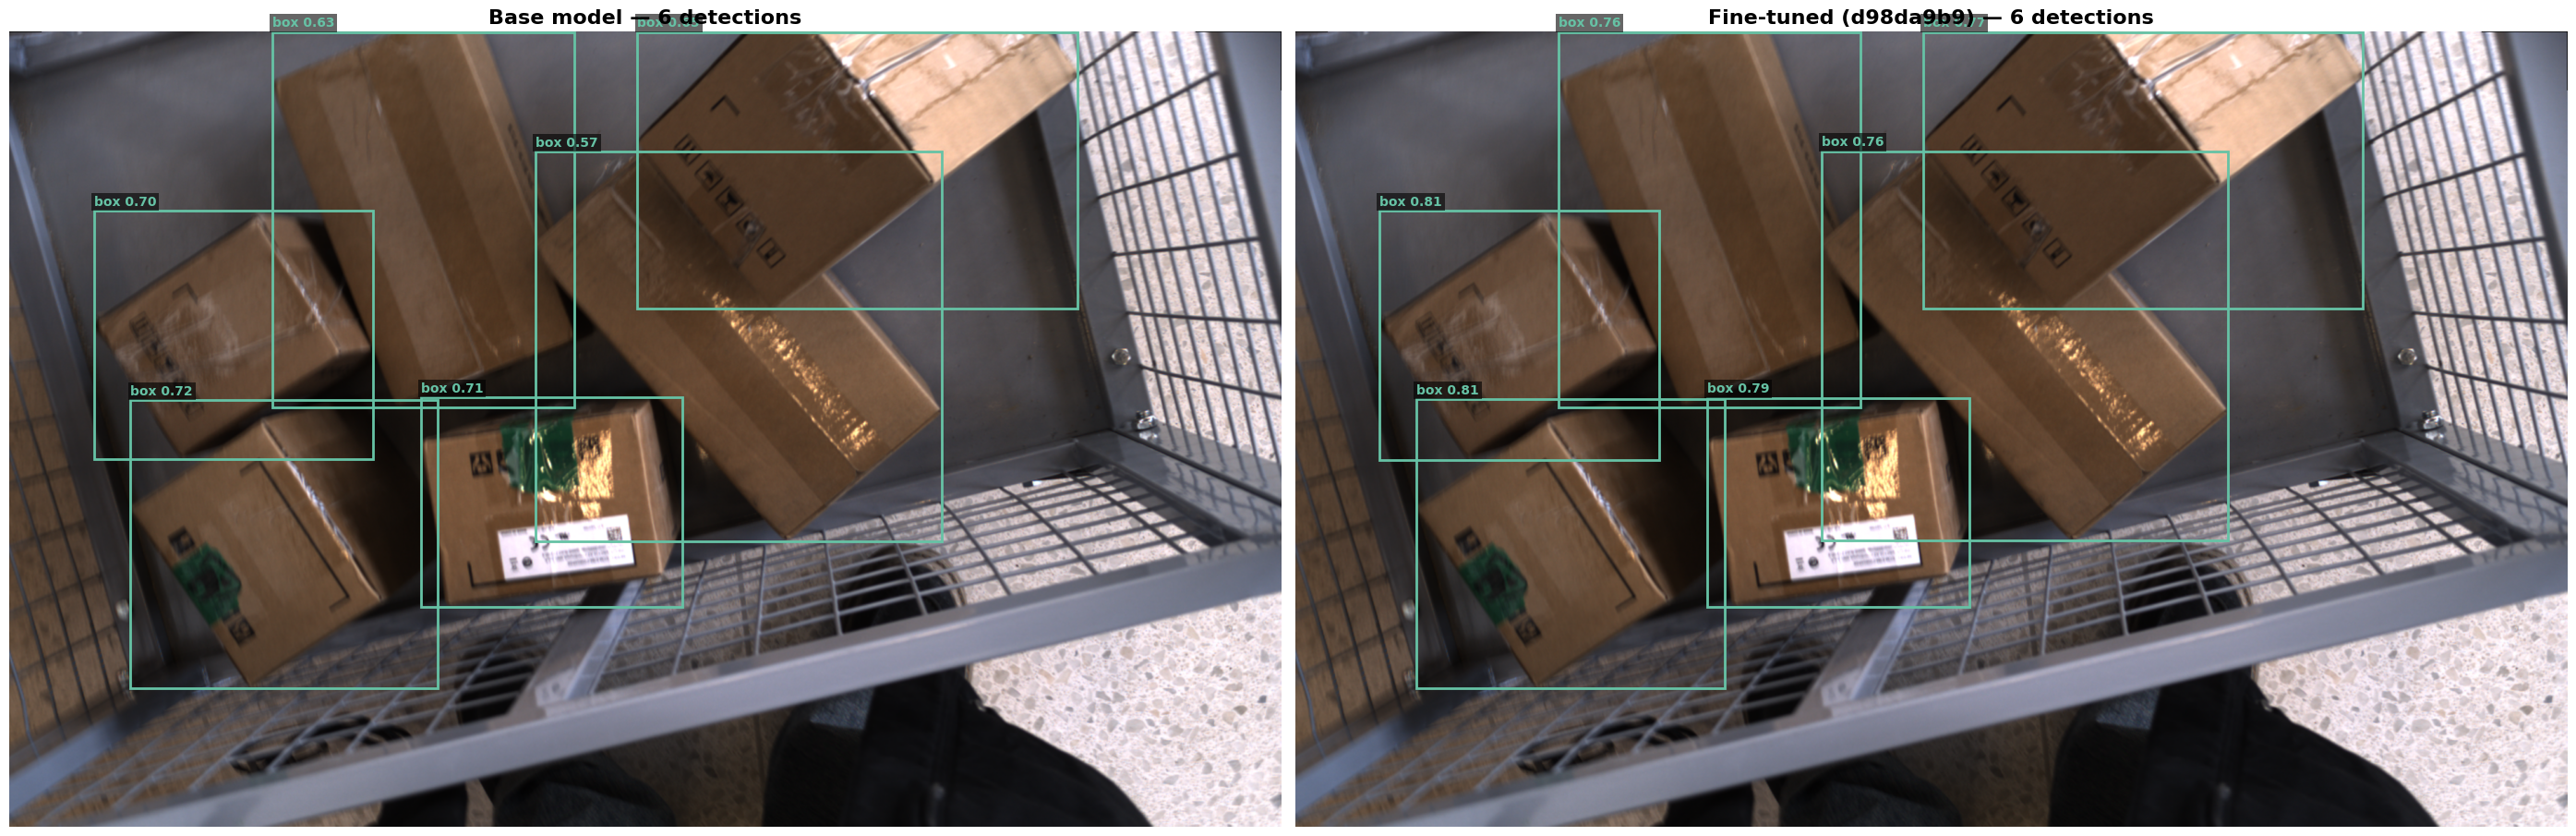

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_base = dino_detector.detect(image_bgr, ["box"])
result_ft = finetuned_detector.detect(image_bgr, ["box"])

fig, axes = plt.subplots(1, 2, figsize=(28, 10))

for ax, result, title in [
    (axes[0], result_base, f"Base model — {len(result_base.boxes_xyxy)} detections"),
    (axes[1], result_ft, f"Fine-tuned (d98da9b9) — {len(result_ft.boxes_xyxy)} detections"),
]:
    ax.imshow(image_rgb)
    ax.set_title(title, fontsize=16, fontweight='bold')
    colors = plt.cm.Set2.colors
    for box, conf, cid in zip(result.boxes_xyxy, result.confidences, result.class_ids):
        x1, y1, x2, y2 = box
        color = colors[cid % len(colors)]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 8, f'box {conf:.2f}', color=color,
                fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none'))
    ax.set_axis_off()

plt.tight_layout()
plt.show()